# CBIS-DDSM Mammography Dataset Preprocessing Pipeline


## Pipeline Steps:
1. **DICOM to PNG Conversion** - Convert mammography images from DICOM format
2. **ROI Cropping with Padding** - Crop to Region of Interest with 10% padding
3. **CLAHE Enhancement** - Apply Contrast Limited Adaptive Histogram Equalization (clip limit 2.0, grid 8×8)
4. **Image Resizing** - Resize all images to 512×512 pixels
5. **Dataset Organization** - Patient-wise train/test split (80/20) to prevent data leakage

## 1. Setup and Imports


In [1]:
# !pip install pydicom opencv-python pillow pandas numpy scikit-learn tqdm matplotlib torch torchvision

In [2]:
import os
import sys
import warnings
from pathlib import Path
from typing import Dict, List, Tuple, Optional, Any
from dataclasses import dataclass
from collections import defaultdict
import json
from datetime import datetime

import numpy as np
import pandas as pd
import cv2
from PIL import Image
import pydicom

# Use tqdm.notebook for better Jupyter display - ALL with leave=True to persist
from tqdm.notebook import tqdm

from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Configure display settings
warnings.filterwarnings('ignore')
%matplotlib inline

# Print version information
print("ENVIRONMENT SETUP")
print(f"Python version: {sys.version.split()[0]}")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"OpenCV version: {cv2.__version__}")
print(f"PyDicom version: {pydicom.__version__}")
print("\n All imports successful!")


ENVIRONMENT SETUP
Python version: 3.13.5
NumPy version: 2.1.3
Pandas version: 2.2.3
OpenCV version: 4.12.0
PyDicom version: 3.0.1

 All imports successful!


## 2. Configuration

Set up all preprocessing parameters here. Modify the paths to match your system.


In [3]:
@dataclass
class PreprocessingConfig:
    """
    Configuration for preprocessing pipeline.
    All parameters can be modified here before running the pipeline.
    """
    # INPUT/OUTPUT PATHS
    data_root: str = r"D:\Project\data\manifest-ZkhPvrLo5216730872708713142"
    output_root: str = r"D:\Project\data\preprocessed"
    

    # IMAGE PROCESSING PARAMETERS

    target_size: Tuple[int, int] = (512, 512)  # Output image dimensions
    roi_padding: float = 0.10                   # 10% padding around ROI
    

    # CLAHE PARAMETERS
    clahe_clip_limit: float = 2.0              # Contrast limiting threshold
    clahe_tile_grid_size: Tuple[int, int] = (8, 8)  # Grid for local histogram
    

    # SPLIT PARAMETERS
    train_ratio: float = 0.80                  # 80% for training
    test_ratio: float = 0.20                   # 20% for testing
    random_seed: int = 42                      # For reproducibility
    

    # PROCESSING OPTIONS
    use_roi_cropping: bool = True  # Use pre-cropped images if available
    
    def __post_init__(self):
        """Initialize derived paths and create output directories."""
        self.cbis_ddsm_path = os.path.join(self.data_root, "CBIS-DDSM")
        self.output_train = os.path.join(self.output_root, "train")
        self.output_test = os.path.join(self.output_root, "test")
        
        # Create output directory structure for PyTorch ImageFolder
        for split in [self.output_train, self.output_test]:
            for label in ['benign', 'malignant']:
                os.makedirs(os.path.join(split, label), exist_ok=True)


# Create configuration instance
config = PreprocessingConfig()

# Display configuration
print("PREPROCESSING CONFIGURATION")
print(f"Data Root:         {config.data_root}")
print(f"Output Root:       {config.output_root}")
print(f"Target Size:       {config.target_size[0]}×{config.target_size[1]} pixels")
print(f"ROI Padding:       {config.roi_padding * 100}%")
print(f"CLAHE Clip Limit:  {config.clahe_clip_limit}")
print(f"CLAHE Tile Grid:   {config.clahe_tile_grid_size}")
print(f"Train/Test Split:  {config.train_ratio*100}% / {config.test_ratio*100}%")
print(f"Random Seed:       {config.random_seed}")
print(f"Use ROI Cropping:  {config.use_roi_cropping}")


PREPROCESSING CONFIGURATION
Data Root:         D:\Project\data\manifest-ZkhPvrLo5216730872708713142
Output Root:       D:\Project\data\preprocessed
Target Size:       512×512 pixels
ROI Padding:       10.0%
CLAHE Clip Limit:  2.0
CLAHE Tile Grid:   (8, 8)
Train/Test Split:  80.0% / 20.0%
Random Seed:       42
Use ROI Cropping:  True


## 3. Data Structures and Image Processing Functions


In [4]:
@dataclass
class ImageRecord:
    """Data class to store information about each mammography image."""
    patient_id: str
    image_type: str  # 'mass' or 'calc'
    laterality: str  # 'LEFT' or 'RIGHT'
    view: str  # 'CC' or 'MLO'
    abnormality_id: int
    pathology: str  # 'MALIGNANT', 'BENIGN', 'BENIGN_WITHOUT_CALLBACK'
    full_mammogram_path: str
    cropped_image_path: Optional[str] = None
    roi_mask_path: Optional[str] = None
    original_set: str = ""
    processed_path: str = ""
    split: str = ""
    
    @property
    def label(self) -> str:
        return 'malignant' if 'MALIGNANT' in self.pathology else 'benign'
    
    @property
    def label_binary(self) -> int:
        return 1 if 'MALIGNANT' in self.pathology else 0


def resolve_dicom_path(relative_path: str, cbis_ddsm_path: str) -> str:
    """Resolve the DICOM file path from CSV relative path."""
    if pd.isna(relative_path) or str(relative_path) == 'nan':
        return ""
    relative_path = str(relative_path).strip().strip('"')
    parts = relative_path.replace('\\', '/').split('/')
    folder_name = parts[0]
    folder_path = os.path.join(cbis_ddsm_path, folder_name)
    if os.path.exists(folder_path):
        for root, dirs, files in os.walk(folder_path):
            for f in files:
                if f.endswith('.dcm'):
                    return os.path.join(root, f)
    return ""


def read_dicom(dicom_path: str) -> Optional[np.ndarray]:
    """Read a DICOM file and return normalized uint8 image."""
    if not dicom_path or not os.path.exists(dicom_path):
        return None
    try:
        dcm = pydicom.dcmread(dicom_path, force=True)
        if not hasattr(dcm, 'pixel_array'):
            return None
        img = dcm.pixel_array.astype(np.float32)
        
        # Handle MONOCHROME1 (inverted)
        if hasattr(dcm, 'PhotometricInterpretation'):
            if dcm.PhotometricInterpretation == 'MONOCHROME1':
                img = img.max() - img
        
        # Apply window/level if available
        if hasattr(dcm, 'WindowCenter') and hasattr(dcm, 'WindowWidth'):
            center = dcm.WindowCenter
            width = dcm.WindowWidth
            if isinstance(center, pydicom.multival.MultiValue):
                center = center[0]
            if isinstance(width, pydicom.multival.MultiValue):
                width = width[0]
            img_min = center - width // 2
            img_max = center + width // 2
            img = np.clip(img, img_min, img_max)
        
        # Normalize to 0-255
        if img.max() > img.min():
            img = ((img - img.min()) / (img.max() - img.min()) * 255).astype(np.uint8)
        else:
            img = np.zeros_like(img, dtype=np.uint8)
        return img
    except:
        return None


def read_roi_mask(mask_path: str) -> Optional[np.ndarray]:
    """Read ROI mask from DICOM file."""
    if not mask_path or not os.path.exists(mask_path):
        return None
    try:
        dcm = pydicom.dcmread(mask_path, force=True)
        if hasattr(dcm, 'pixel_array'):
            mask = dcm.pixel_array
            mask = (mask > 0).astype(np.uint8) * 255
            return mask
        return None
    except:
        return None


def crop_roi_with_padding(image: np.ndarray, mask: Optional[np.ndarray] = None, padding: float = 0.10) -> np.ndarray:
    """Crop image to ROI with specified padding."""
    if mask is not None and mask.shape == image.shape:
        coords = cv2.findNonZero(mask)
    else:
        _, binary = cv2.threshold(image, 10, 255, cv2.THRESH_BINARY)
        coords = cv2.findNonZero(binary)
    
    if coords is None:
        return image
    
    x, y, w, h = cv2.boundingRect(coords)
    pad_x = int(w * padding)
    pad_y = int(h * padding)
    x1 = max(0, x - pad_x)
    y1 = max(0, y - pad_y)
    x2 = min(image.shape[1], x + w + pad_x)
    y2 = min(image.shape[0], y + h + pad_y)
    return image[y1:y2, x1:x2]


def apply_clahe(image: np.ndarray, clip_limit: float = 2.0, tile_grid_size: Tuple[int, int] = (8, 8)) -> np.ndarray:
    """Apply CLAHE (Contrast Limited Adaptive Histogram Equalization)."""
    if image.dtype != np.uint8:
        if image.max() > 255:
            image = ((image - image.min()) / (image.max() - image.min()) * 255).astype(np.uint8)
        else:
            image = image.astype(np.uint8)
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    return clahe.apply(image)


def resize_image(image: np.ndarray, target_size: Tuple[int, int] = (512, 512)) -> np.ndarray:
    """
    Resize image to target size with aspect ratio preservation.
    
    Uses REFLECTION PADDING instead of black borders to:
        - Preserve edge texture for CNNs
        - Avoid sharp black edge artifacts that cause false positives
        - Maintain natural tissue appearance at boundaries
    """
    h, w = image.shape[:2]
    target_h, target_w = target_size
    scale = min(target_w / w, target_h / h)
    new_w = int(w * scale)
    new_h = int(h * scale)
    resized = cv2.resize(image, (new_w, new_h), interpolation=cv2.INTER_AREA)
    
    # Calculate padding needed on each side
    pad_top = (target_h - new_h) // 2
    pad_bottom = target_h - new_h - pad_top
    pad_left = (target_w - new_w) // 2
    pad_right = target_w - new_w - pad_left
    
    # Use REFLECTION PADDING instead of black borders
    # This mirrors the image at boundaries, preserving texture
    padded = cv2.copyMakeBorder(
        resized,
        pad_top, pad_bottom, pad_left, pad_right,
        borderType=cv2.BORDER_REFLECT
    )
    return padded


print(" Data structures and image processing functions defined!")


 Data structures and image processing functions defined!


## 4. Load Case Description CSV Files


In [5]:
def load_case_descriptions(config: PreprocessingConfig) -> Tuple[List[ImageRecord], Dict]:
    """Load and parse all case description CSV files."""
    records = []
    patient_records = defaultdict(list)
    
    csv_files = [
        ('mass_case_description_train_set.csv', 'mass', 'training'),
        ('mass_case_description_test_set.csv', 'mass', 'test'),
        ('calc_case_description_train_set.csv', 'calc', 'training'),
        ('calc_case_description_test_set.csv', 'calc', 'test'),
    ]
    

    print("STEP 1: LOADING CASE DESCRIPTIONS")
    print("="*60 + "\n")
    
    # Progress bar for loading CSV files (leave=True to PERSIST after completion)
    for csv_name, image_type, original_set in tqdm(csv_files, desc="Loading CSV files", leave=True):
        csv_path = os.path.join(config.data_root, csv_name)
        
        if not os.path.exists(csv_path):
            print(f"  ⚠ Warning: CSV file not found: {csv_name}")
            continue
        
        df = pd.read_csv(csv_path)
        count = 0
        
        for _, row in df.iterrows():
            patient_id = str(row['patient_id'])
            laterality = str(row['left or right breast']).upper()
            view = str(row['image view']).upper()
            abnormality_id = int(row['abnormality id'])
            pathology = str(row['pathology']).upper()
            
            full_mammo_path = resolve_dicom_path(str(row['image file path']), config.cbis_ddsm_path)
            
            cropped_path = None
            roi_mask_path = None
            
            if 'cropped image file path' in row and pd.notna(row['cropped image file path']):
                cropped_path = resolve_dicom_path(str(row['cropped image file path']), config.cbis_ddsm_path)
                
            if 'ROI mask file path' in row and pd.notna(row['ROI mask file path']):
                roi_mask_path = resolve_dicom_path(str(row['ROI mask file path']), config.cbis_ddsm_path)
            
            record = ImageRecord(
                patient_id=patient_id,
                image_type=image_type,
                laterality=laterality,
                view=view,
                abnormality_id=abnormality_id,
                pathology=pathology,
                full_mammogram_path=full_mammo_path,
                cropped_image_path=cropped_path,
                roi_mask_path=roi_mask_path,
                original_set=original_set
            )
            records.append(record)
            count += 1
        
        print(f"  Loaded {count:>4} records from {csv_name}")
    
    # Group by patient
    for record in records:
        patient_records[record.patient_id].append(record)
    
    return records, patient_records


# Load the data
records, patient_records = load_case_descriptions(config)

print(f"Total: {len(records)} image records from {len(patient_records)} patients")

STEP 1: LOADING CASE DESCRIPTIONS



Loading CSV files:   0%|          | 0/4 [00:00<?, ?it/s]

  Loaded 1318 records from mass_case_description_train_set.csv
  Loaded  378 records from mass_case_description_test_set.csv
  Loaded 1546 records from calc_case_description_train_set.csv
  Loaded  326 records from calc_case_description_test_set.csv
Total: 3568 image records from 1566 patients


## 5. Patient-Wise Train/Test Split

**Critical:** All images from the same patient must stay in the same split to prevent data leakage.


In [6]:
def perform_patient_wise_split(records: List[ImageRecord], patient_records: Dict, config: PreprocessingConfig):
    """Split patients into train/test sets to prevent data leakage."""
    print("STEP 2: PATIENT-WISE TRAIN/TEST SPLIT")
    
    patients = list(patient_records.keys())
    
    # Determine majority label for each patient (leave=True for persistent progress bar)
    patient_labels = []
    for patient_id in tqdm(patients, desc="Analyzing patient labels", leave=True):
        patient_recs = patient_records[patient_id]
        malignant_count = sum(1 for r in patient_recs if 'MALIGNANT' in r.pathology)
        benign_count = len(patient_recs) - malignant_count
        patient_labels.append(1 if malignant_count > benign_count else 0)
    
    # Stratified split
    train_patients, test_patients = train_test_split(
        patients,
        test_size=config.test_ratio,
        random_state=config.random_seed,
        stratify=patient_labels
    )
    
    # Assign split to TRAINING records (leave=True for persistent progress bar)
    for patient_id in tqdm(train_patients, desc="Assigning TRAIN patients", leave=True):
        for record in patient_records[patient_id]:
            record.split = 'train'
    
    # Assign split to TEST records (leave=True for persistent progress bar)
    for patient_id in tqdm(test_patients, desc="Assigning TEST patients", leave=True):
        for record in patient_records[patient_id]:
            record.split = 'test'
    
    return train_patients, test_patients


# Perform the split
train_patients, test_patients = perform_patient_wise_split(records, patient_records, config)

# Calculate statistics
train_images = sum(1 for r in records if r.split == 'train')
test_images = sum(1 for r in records if r.split == 'test')


print("SPLIT RESULTS")
print(f"\nTrain Set: {len(train_patients):>5} patients, {train_images:>5} images")
print(f"Test Set:  {len(test_patients):>5} patients, {test_images:>5} images")

# Verify no patient overlap
overlap = set(train_patients) & set(test_patients)
if len(overlap) == 0:
    print(f"\nVerified: No patient overlap between train and test sets!")
else:
    print(f"\nWARNING: {len(overlap)} patients appear in both splits!")


STEP 2: PATIENT-WISE TRAIN/TEST SPLIT


Analyzing patient labels:   0%|          | 0/1566 [00:00<?, ?it/s]

Assigning TRAIN patients:   0%|          | 0/1252 [00:00<?, ?it/s]

Assigning TEST patients:   0%|          | 0/314 [00:00<?, ?it/s]

SPLIT RESULTS

Train Set:  1252 patients,  2810 images
Test Set:    314 patients,   758 images

Verified: No patient overlap between train and test sets!


## 6. Process All Images

Execute the complete preprocessing pipeline with **separate persistent progress bars** for train and test sets.


In [7]:
def process_single_image(record: ImageRecord, config: PreprocessingConfig) -> bool:
    """Process a single image through the entire pipeline."""
    try:
        # Determine image path
        if config.use_roi_cropping and record.cropped_image_path:
            image_path = record.cropped_image_path
            mask_path = None
        else:
            image_path = record.full_mammogram_path
            mask_path = record.roi_mask_path
        
        # Read image
        image = read_dicom(image_path)
        if image is None:
            if record.full_mammogram_path:
                image = read_dicom(record.full_mammogram_path)
            if image is None:
                return False
        
        # Read mask if needed
        mask = None
        if mask_path and not record.cropped_image_path:
            mask = read_roi_mask(mask_path)
            if mask is not None and mask.shape != image.shape:
                mask = cv2.resize(mask, (image.shape[1], image.shape[0]))
        
        # Step 1: Crop ROI with 10% padding
        if not record.cropped_image_path:
            image = crop_roi_with_padding(image, mask, config.roi_padding)
        
        # Step 2: Apply CLAHE enhancement
        image = apply_clahe(image, config.clahe_clip_limit, config.clahe_tile_grid_size)
        
        # Step 3: Resize to target size
        image = resize_image(image, config.target_size)
        
        # Determine output path
        label = record.label
        split_dir = config.output_train if record.split == 'train' else config.output_test
        
        filename = f"{record.patient_id}_{record.image_type}_{record.laterality}_{record.view}_{record.abnormality_id}.png"
        output_path = os.path.join(split_dir, label, filename)
        
        # Save as PNG
        cv2.imwrite(output_path, image)
        record.processed_path = output_path
        
        return True
    except:
        return False


print("Processing function defined!")


Processing function defined!


In [8]:
# Process all images with detailed progress tracking
print("STEP 3: PROCESSING ALL IMAGES")

# Initialize statistics
stats = {
    'total': len(records),
    'successful': 0,
    'failed': 0,
    'train': 0,
    'test': 0,
    'malignant': 0,
    'benign': 0
}

# Separate records by split
train_records = [r for r in records if r.split == 'train']
test_records = [r for r in records if r.split == 'test']

print(f"Processing {len(train_records)} training images...")

# Process TRAINING images with PERSISTENT progress bar (leave=True)
for record in tqdm(train_records, desc="Processing TRAIN images", leave=True):
    success = process_single_image(record, config)
    
    if success:
        stats['successful'] += 1
        stats['train'] += 1
        if 'MALIGNANT' in record.pathology:
            stats['malignant'] += 1
        else:
            stats['benign'] += 1
    else:
        stats['failed'] += 1

print(f"\nProcessing {len(test_records)} test images...")

# Process TEST images with PERSISTENT progress bar (leave=True)
for record in tqdm(test_records, desc="Processing TEST images", leave=True):
    success = process_single_image(record, config)
    
    if success:
        stats['successful'] += 1
        stats['test'] += 1
        if 'MALIGNANT' in record.pathology:
            stats['malignant'] += 1
        else:
            stats['benign'] += 1
    else:
        stats['failed'] += 1

# Print results
print("PROCESSING COMPLETE")
print(f"\n Successfully processed: {stats['successful']}/{stats['total']} images")
print(f" Failed: {stats['failed']} images")
print(f"\nTrain set: {stats['train']} images")
print(f"Test set:  {stats['test']} images")
print(f"\nMalignant: {stats['malignant']} images")
print(f"Benign:    {stats['benign']} images")


STEP 3: PROCESSING ALL IMAGES
Processing 2810 training images...


Processing TRAIN images:   0%|          | 0/2810 [00:00<?, ?it/s]


Processing 758 test images...


Processing TEST images:   0%|          | 0/758 [00:00<?, ?it/s]

PROCESSING COMPLETE

 Successfully processed: 3568/3568 images
 Failed: 0 images

Train set: 2810 images
Test set:  758 images

Malignant: 1457 images
Benign:    2111 images


## 7. Generate Metadata CSV Files


In [9]:
print("STEP 4: GENERATING METADATA WITH CLASS WEIGHTS")

# Generate metadata with PERSISTENT progress bar (leave=True)
metadata = []

for record in tqdm(records, desc="Generating metadata", leave=True):
    if record.processed_path:
        metadata.append({
            'patient_id': record.patient_id,
            'image_type': record.image_type,
            'laterality': record.laterality,
            'view': record.view,
            'abnormality_id': record.abnormality_id,
            'pathology': record.pathology,
            'label': record.label,
            'label_binary': record.label_binary,
            'split': record.split,
            'original_set': record.original_set,
            'processed_path': record.processed_path,
            'original_full_path': record.full_mammogram_path,
            'original_cropped_path': record.cropped_image_path or '',
            'original_mask_path': record.roi_mask_path or ''
        })

df_metadata = pd.DataFrame(metadata)

# Calculate class weights from TRAINING SET distribution
# This addresses class imbalance by giving minority class higher weight
train_df = df_metadata[df_metadata['split'] == 'train']
total_train = len(train_df)

train_benign_count = len(train_df[train_df['label'] == 'benign'])
train_malignant_count = len(train_df[train_df['label'] == 'malignant'])

# Weight formula: Total / (2 * Count) - higher weight for minority class
weight_benign = total_train / (2 * train_benign_count) if train_benign_count > 0 else 1.0
weight_malignant = total_train / (2 * train_malignant_count) if train_malignant_count > 0 else 1.0

print(f"Class distribution in training set:")
print(f"  Benign:    {train_benign_count} samples, weight = {weight_benign:.4f}")
print(f"  Malignant: {train_malignant_count} samples, weight = {weight_malignant:.4f}")

# Add class_weight column based on label
df_metadata['class_weight'] = df_metadata['label'].apply(
    lambda x: weight_malignant if x == 'malignant' else weight_benign
)

# Save complete metadata
metadata_path = os.path.join(config.output_root, 'metadata.csv')
df_metadata.to_csv(metadata_path, index=False)

# Save separate train/test metadata (with class weights)
train_df = df_metadata[df_metadata['split'] == 'train']
test_df = df_metadata[df_metadata['split'] == 'test']

train_df.to_csv(os.path.join(config.output_root, 'train_metadata.csv'), index=False)
test_df.to_csv(os.path.join(config.output_root, 'test_metadata.csv'), index=False)

print(f"\n Complete metadata: {metadata_path}")
print(f" Train metadata: {os.path.join(config.output_root, 'train_metadata.csv')} (includes class_weight)")
print(f" Test metadata: {os.path.join(config.output_root, 'test_metadata.csv')}")

# Display sample
print("\n--- Sample Metadata (with class_weight column) ---")
df_metadata.head(10)


STEP 4: GENERATING METADATA WITH CLASS WEIGHTS


Generating metadata:   0%|          | 0/3568 [00:00<?, ?it/s]

Class distribution in training set:
  Benign:    1641 samples, weight = 0.8562
  Malignant: 1169 samples, weight = 1.2019

 Complete metadata: D:\Project\data\preprocessed\metadata.csv
 Train metadata: D:\Project\data\preprocessed\train_metadata.csv (includes class_weight)
 Test metadata: D:\Project\data\preprocessed\test_metadata.csv

--- Sample Metadata (with class_weight column) ---


,patient_id,image_type,laterality,view,abnormality_id,pathology,label,label_binary,split,original_set,processed_path,original_full_path,original_cropped_path,original_mask_path,class_weight
0,P_00001,mass,LEFT,CC,1,MALIGNANT,malignant,1,test,training,D:\Project\data\preprocessed\test\malignant\P_...,D:\Project\data\manifest-ZkhPvrLo5216730872708...,D:\Project\data\manifest-ZkhPvrLo5216730872708...,D:\Project\data\manifest-ZkhPvrLo5216730872708...,1.201882
1,P_00001,mass,LEFT,MLO,1,MALIGNANT,malignant,1,test,training,D:\Project\data\preprocessed\test\malignant\P_...,D:\Project\data\manifest-ZkhPvrLo5216730872708...,D:\Project\data\manifest-ZkhPvrLo5216730872708...,D:\Project\data\manifest-ZkhPvrLo5216730872708...,1.201882
2,P_00004,mass,LEFT,CC,1,BENIGN,benign,0,train,training,D:\Project\data\preprocessed\train\benign\P_00...,D:\Project\data\manifest-ZkhPvrLo5216730872708...,D:\Project\data\manifest-ZkhPvrLo5216730872708...,D:\Project\data\manifest-ZkhPvrLo5216730872708...,0.856185
3,P_00004,mass,LEFT,MLO,1,BENIGN,benign,0,train,training,D:\Project\data\preprocessed\train\benign\P_00...,D:\Project\data\manifest-ZkhPvrLo5216730872708...,D:\Project\data\manifest-ZkhPvrLo5216730872708...,D:\Project\data\manifest-ZkhPvrLo5216730872708...,0.856185
4,P_00004,mass,RIGHT,MLO,1,BENIGN,benign,0,train,training,D:\Project\data\preprocessed\train\benign\P_00...,D:\Project\data\manifest-ZkhPvrLo5216730872708...,D:\Project\data\manifest-ZkhPvrLo5216730872708...,D:\Project\data\manifest-ZkhPvrLo5216730872708...,0.856185
5,P_00009,mass,RIGHT,CC,1,MALIGNANT,malignant,1,train,training,D:\Project\data\preprocessed\train\malignant\P...,D:\Project\data\manifest-ZkhPvrLo5216730872708...,D:\Project\data\manifest-ZkhPvrLo5216730872708...,D:\Project\data\manifest-ZkhPvrLo5216730872708...,1.201882
6,P_00009,mass,RIGHT,MLO,1,MALIGNANT,malignant,1,train,training,D:\Project\data\preprocessed\train\malignant\P...,D:\Project\data\manifest-ZkhPvrLo5216730872708...,D:\Project\data\manifest-ZkhPvrLo5216730872708...,D:\Project\data\manifest-ZkhPvrLo5216730872708...,1.201882
7,P_00015,mass,LEFT,MLO,1,MALIGNANT,malignant,1,test,training,D:\Project\data\preprocessed\test\malignant\P_...,D:\Project\data\manifest-ZkhPvrLo5216730872708...,D:\Project\data\manifest-ZkhPvrLo5216730872708...,D:\Project\data\manifest-ZkhPvrLo5216730872708...,1.201882
8,P_00018,mass,RIGHT,CC,1,BENIGN,benign,0,test,training,D:\Project\data\preprocessed\test\benign\P_000...,D:\Project\data\manifest-ZkhPvrLo5216730872708...,D:\Project\data\manifest-ZkhPvrLo5216730872708...,D:\Project\data\manifest-ZkhPvrLo5216730872708...,0.856185
9,P_00018,mass,RIGHT,MLO,1,BENIGN,benign,0,test,training,D:\Project\data\preprocessed\test\benign\P_000...,D:\Project\data\manifest-ZkhPvrLo5216730872708...,D:\Project\data\manifest-ZkhPvrLo5216730872708...,D:\Project\data\manifest-ZkhPvrLo5216730872708...,0.856185


## 8. Final Summary and Visualization


In [10]:
# Print comprehensive summary
print("PREPROCESSING SUMMARY")

print(f"\nTotal processed images: {len(df_metadata)}")
print(f"Total unique patients: {df_metadata['patient_id'].nunique()}")

print("\n--- Split Distribution ---")
print(f"Train: {len(train_df)} images from {train_df['patient_id'].nunique()} patients")
print(f"Test:  {len(test_df)} images from {test_df['patient_id'].nunique()} patients")

print("\n--- Label Distribution ---")
print(f"\nTrain set:")
print(f"  Benign:    {len(train_df[train_df['label'] == 'benign']):>5}")
print(f"  Malignant: {len(train_df[train_df['label'] == 'malignant']):>5}")
print(f"\nTest set:")
print(f"  Benign:    {len(test_df[test_df['label'] == 'benign']):>5}")
print(f"  Malignant: {len(test_df[test_df['label'] == 'malignant']):>5}")

# Save summary JSON
summary = {
    'total_images': len(df_metadata),
    'unique_patients': int(df_metadata['patient_id'].nunique()),
    'train_images': len(train_df),
    'train_patients': int(train_df['patient_id'].nunique()),
    'test_images': len(test_df),
    'test_patients': int(test_df['patient_id'].nunique()),
    'train_malignant': int(len(train_df[train_df['label'] == 'malignant'])),
    'train_benign': int(len(train_df[train_df['label'] == 'benign'])),
    'test_malignant': int(len(test_df[test_df['label'] == 'malignant'])),
    'test_benign': int(len(test_df[test_df['label'] == 'benign'])),
    'config': {
        'target_size': list(config.target_size),
        'roi_padding': config.roi_padding,
        'clahe_clip_limit': config.clahe_clip_limit,
        'clahe_tile_grid_size': list(config.clahe_tile_grid_size),
        'train_ratio': config.train_ratio,
        'random_seed': config.random_seed
    },
    'timestamp': datetime.now().isoformat()
}

summary_path = os.path.join(config.output_root, 'preprocessing_summary.json')
with open(summary_path, 'w') as f:
    json.dump(summary, f, indent=2)

print(f"\n Summary saved to: {summary_path}")


PREPROCESSING SUMMARY

Total processed images: 3568
Total unique patients: 1566

--- Split Distribution ---
Train: 2810 images from 1252 patients
Test:  758 images from 314 patients

--- Label Distribution ---

Train set:
  Benign:     1641
  Malignant:  1169

Test set:
  Benign:      470
  Malignant:   288

 Summary saved to: D:\Project\data\preprocessed\preprocessing_summary.json


STEP 5: SAMPLE PROCESSED IMAGES


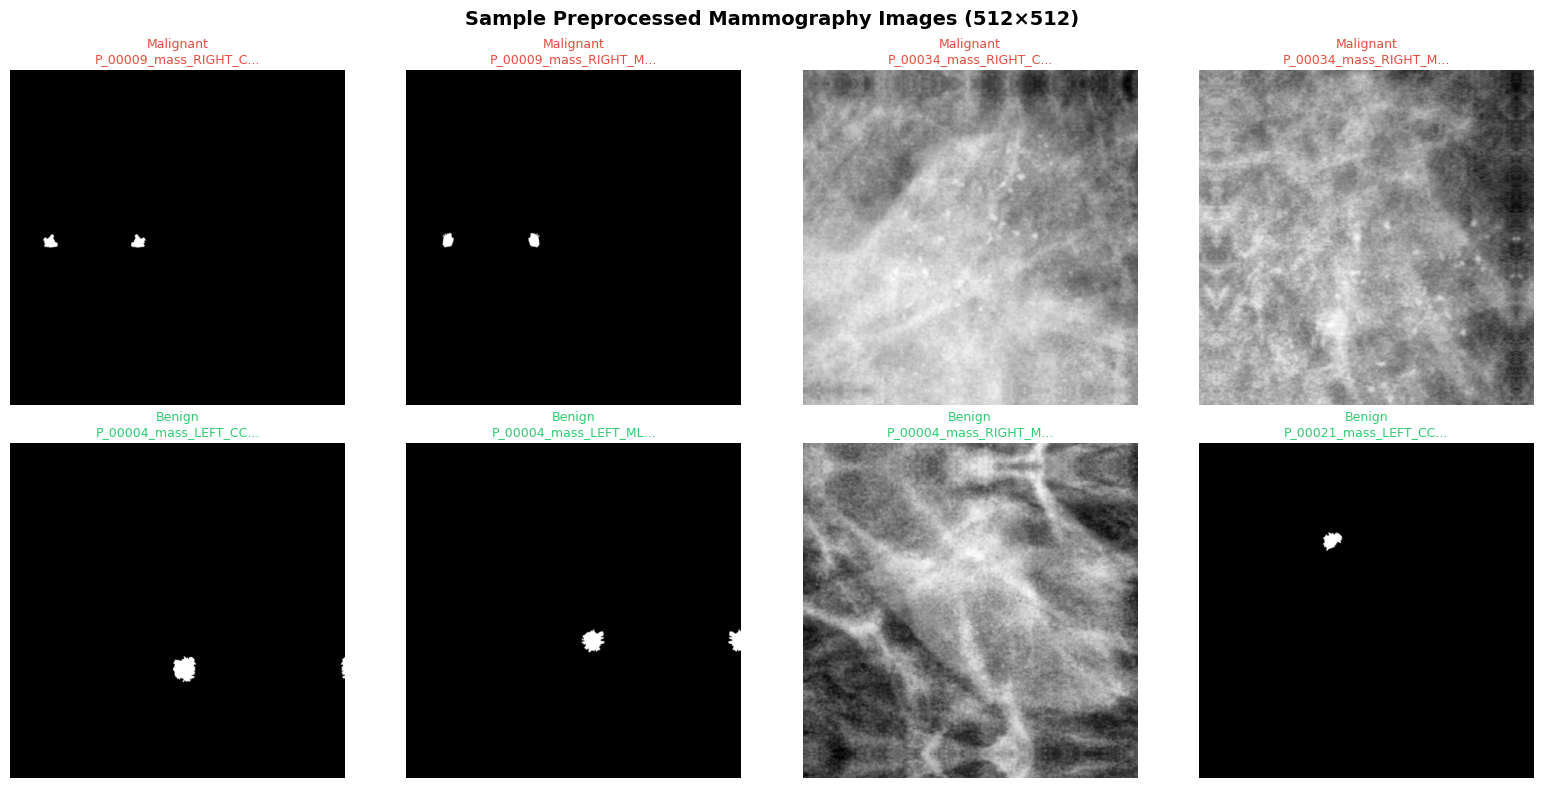


 Visualization saved to: D:\Project\data\preprocessed\sample_visualization.png
PREPROCESSING PIPELINE COMPLETE!

Output directory: D:\Project\data\preprocessed

Files created:
  ├── train/
  │   ├── benign/     (1641 images)
  │   └── malignant/  (1169 images)
  ├── test/
  │   ├── benign/     (470 images)
  │   └── malignant/  (288 images)
  ├── metadata.csv
  ├── train_metadata.csv
  ├── test_metadata.csv
  ├── preprocessing_summary.json
  └── sample_visualization.png



In [11]:
# Visualize sample processed images
print("STEP 5: SAMPLE PROCESSED IMAGES")

# Get sample images from each category
train_malignant = train_df[train_df['label'] == 'malignant']['processed_path'].tolist()[:4]
train_benign = train_df[train_df['label'] == 'benign']['processed_path'].tolist()[:4]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

# Plot malignant samples
for i, path in enumerate(train_malignant):
    if os.path.exists(path):
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        axes[0, i].imshow(img, cmap='gray')
        axes[0, i].set_title(f'Malignant\n{os.path.basename(path)[:20]}...', fontsize=9, color='#e74c3c')
        axes[0, i].axis('off')

# Plot benign samples
for i, path in enumerate(train_benign):
    if os.path.exists(path):
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        axes[1, i].imshow(img, cmap='gray')
        axes[1, i].set_title(f'Benign\n{os.path.basename(path)[:20]}...', fontsize=9, color='#2ecc71')
        axes[1, i].axis('off')

plt.suptitle(f'Sample Preprocessed Mammography Images ({config.target_size[0]}×{config.target_size[1]})', 
             fontsize=14, fontweight='bold')
plt.tight_layout()

viz_path = os.path.join(config.output_root, 'sample_visualization.png')
plt.savefig(viz_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"\n Visualization saved to: {viz_path}")


print("PREPROCESSING PIPELINE COMPLETE!")
print(f"\nOutput directory: {config.output_root}")
print(f"""
Files created:
  ├── train/
  │   ├── benign/     ({len(train_df[train_df['label']=='benign'])} images)
  │   └── malignant/  ({len(train_df[train_df['label']=='malignant'])} images)
  ├── test/
  │   ├── benign/     ({len(test_df[test_df['label']=='benign'])} images)
  │   └── malignant/  ({len(test_df[test_df['label']=='malignant'])} images)
  ├── metadata.csv
  ├── train_metadata.csv
  ├── test_metadata.csv
  ├── preprocessing_summary.json
  └── sample_visualization.png
""")


## 9. PyTorch Data Loading

Examples of how to load the preprocessed data for training with PyTorch.


In [12]:
# Check if PyTorch is available
try:
    import torch
    import torchvision
    from torch.utils.data import Dataset, DataLoader
    import torchvision.transforms as transforms
    
    print(f"PyTorch version: {torch.__version__}")
    print(f"TorchVision version: {torchvision.__version__}")
    print(f"CUDA available: {torch.cuda.is_available()}")
    if torch.cuda.is_available():
        print(f"CUDA device: {torch.cuda.get_device_name(0)}")
    PYTORCH_AVAILABLE = True
except ImportError:
    print("PyTorch not installed. Run: pip install torch torchvision")
    PYTORCH_AVAILABLE = False


PyTorch version: 2.9.1+cu128
TorchVision version: 0.24.1+cu128
CUDA available: True
CUDA device: NVIDIA GeForce RTX 5090


In [13]:
if PYTORCH_AVAILABLE:
    class CBISDDSMDataset(Dataset):
        """
        PyTorch Dataset for CBIS-DDSM preprocessed mammography images.
        
        This provides more control than ImageFolder, allowing access to
        patient IDs and other metadata during training.
        
        Example:
            >>> train_transform = transforms.Compose([
            ...     transforms.ToTensor(),
            ...     transforms.Normalize(mean=[0.5], std=[0.5])
            ... ])
            >>> dataset = CBISDDSMDataset('train_metadata.csv', transform=train_transform)
            >>> dataloader = DataLoader(dataset, batch_size=32, shuffle=True)
        """
        
        def __init__(self, metadata_csv: str, transform=None):
            """
            Args:
                metadata_csv: Path to train or test metadata CSV
                transform: Optional torchvision transforms to apply
            """
            self.df = pd.read_csv(metadata_csv)
            self.transform = transform
            
        def __len__(self) -> int:
            return len(self.df)
        
        def __getitem__(self, idx: int):
            row = self.df.iloc[idx]
            
            # Load image
            image = cv2.imread(row['processed_path'], cv2.IMREAD_GRAYSCALE)
            
            # Convert to PIL for torchvision compatibility
            image = Image.fromarray(image)
            
            # Apply transforms
            if self.transform:
                image = self.transform(image)
            
            # Get label
            label = row['label_binary']
            
            return image, label
        
        def get_patient_id(self, idx: int) -> str:
            """Get patient ID for a sample (useful for debugging/analysis)."""
            return self.df.iloc[idx]['patient_id']
        
        def get_class_weights(self) -> torch.Tensor:
            """Calculate class weights for handling class imbalance."""
            counts = self.df['label_binary'].value_counts().sort_index()
            weights = 1.0 / counts.values
            weights = weights / weights.sum() * 2  # Normalize
            return torch.FloatTensor(weights)
    
    print("CBISDDSMDataset class defined!")


CBISDDSMDataset class defined!


In [14]:
if PYTORCH_AVAILABLE:
    # Define transforms for training (with data augmentation)
    train_transform = transforms.Compose([
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(degrees=10),
        transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5], std=[0.5])  # Normalize to [-1, 1]
    ])
    
    # Simpler transforms for validation/test (no augmentation)
    test_transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5], std=[0.5])
    ])
    
    # Create datasets
    train_metadata = os.path.join(config.output_root, 'train_metadata.csv')
    test_metadata = os.path.join(config.output_root, 'test_metadata.csv')
    
    if os.path.exists(train_metadata) and os.path.exists(test_metadata):
        train_dataset = CBISDDSMDataset(train_metadata, transform=train_transform)
        test_dataset = CBISDDSMDataset(test_metadata, transform=test_transform)
        
        print(f"\nTrain dataset: {len(train_dataset)} samples")
        print(f"Test dataset:  {len(test_dataset)} samples")
        
        # Create DataLoaders
        train_loader = DataLoader(
            train_dataset, 
            batch_size=32, 
            shuffle=True,
            num_workers=0,  # Set to 0 for Windows compatibility
            pin_memory=True if torch.cuda.is_available() else False
        )
        
        test_loader = DataLoader(
            test_dataset, 
            batch_size=32, 
            shuffle=False,
            num_workers=0,
            pin_memory=True if torch.cuda.is_available() else False
        )
        
        print(f"\nTrain batches: {len(train_loader)}")
        print(f"Test batches:  {len(test_loader)}")
        
        # Test loading a batch
        images, labels = next(iter(train_loader))
        print(f"\nSample batch:")
        print(f"  Images shape: {images.shape}")  # [batch, channels, height, width]
        print(f"  Labels shape: {labels.shape}")
        print(f"  Label values: {labels.tolist()[:10]}...")
        
        # Get class weights for handling imbalance
        class_weights = train_dataset.get_class_weights()
        print(f"\nClass weights (for CrossEntropyLoss):")
        print(f"  Benign (0):    {class_weights[0]:.4f}")
        print(f"  Malignant (1): {class_weights[1]:.4f}")
    else:
        print("Metadata files not found. Run preprocessing cells first.")



Train dataset: 2810 samples
Test dataset:  758 samples

Train batches: 88
Test batches:  24

Sample batch:
  Images shape: torch.Size([32, 1, 512, 512])
  Labels shape: torch.Size([32])
  Label values: [0, 0, 0, 1, 0, 0, 0, 1, 0, 1]...

Class weights (for CrossEntropyLoss):
  Benign (0):    0.8320
  Malignant (1): 1.1680


## Summary

The preprocessing is complete!

### Output Structure
```
preprocessed/
├── train/
│   ├── benign/     (PNG images)
│   └── malignant/  (PNG images)
├── test/
│   ├── benign/     (PNG images)
│   └── malignant/  (PNG images)
├── metadata.csv
├── train_metadata.csv
├── test_metadata.csv
├── preprocessing_summary.json
└── sample_visualization.png
```

- **Patient-wise splitting**: No data leakage between train/test
- **CLAHE enhancement**: Improved contrast for tissue visualization  
- **Aspect ratio preserved**: Letterboxing maintains proportions
- **PyTorch ready**: Compatible with ImageFolder and custom Dataset
- **All progress bars persist**: Easy to refer back to processing summary

